In [53]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
movies = pd.read_csv("ml-latest-small/movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [55]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [56]:
avg_ratings = ratings.groupby("movieId")["rating"].mean().reset_index()
avg_ratings.rename(columns={"rating": "avg_rating"}, inplace=True)

avg_ratings.head()

,movieId,avg_rating
0,1,3.920930
1,2,3.431818
2,3,3.259615
3,4,2.357143
4,5,3.071429


In [57]:
movies = movies.merge(avg_ratings, on="movieId")
movies.head()

,movieId,title,genres,avg_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143
4,5,Father of the Bride Part II (1995),Comedy,3.071429


In [58]:
movies["genres"] = movies["genres"].apply(lambda x: x.split("|"))

mlb = MultiLabelBinarizer()

genre_features = pd.DataFrame(
    mlb.fit_transform(movies["genres"]),
    columns=mlb.classes_,
    index=movies.index
)

In [59]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)")
movies["year"] = movies["year"].astype(float)

In [64]:
movies["year"] = movies["year"].fillna(movies["year"].median())

In [63]:
movie_features.isna().sum()

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21    13
dtype: int64

In [66]:
movie_features = pd.concat(
    [genre_features, movies[["avg_rating", "year"]]],
    axis=1
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

movie_features = scaler.fit_transform(movie_features)

In [75]:
similarity_matrix = cosine_similarity(movie_features)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=movies["title"],
    columns=movies["title"]
)

In [76]:
def get_similar_movies(movie_title, n=10):
    
    similarity_scores = similarity_df[movie_title].sort_values(ascending=False)
    
    similar_movies = similarity_scores.iloc[1:n+1]
    
    return similar_movies

In [77]:
get_similar_movies("Matrix, The (1999)")

title
eXistenZ (1999)                               0.996685
Equilibrium (2002)                            0.996252
Universal Soldier: Day of Reckoning (2012)    0.987267
Ready Player One                              0.984912
They Live (1988)                              0.984552
Terminator, The (1984)                        0.981521
Blade Runner (1982)                           0.979772
Screamers (1995)                              0.979009
Predator (1987)                               0.978076
Death Race 2 (2010)                           0.976375
Name: Matrix, The (1999), dtype: float64

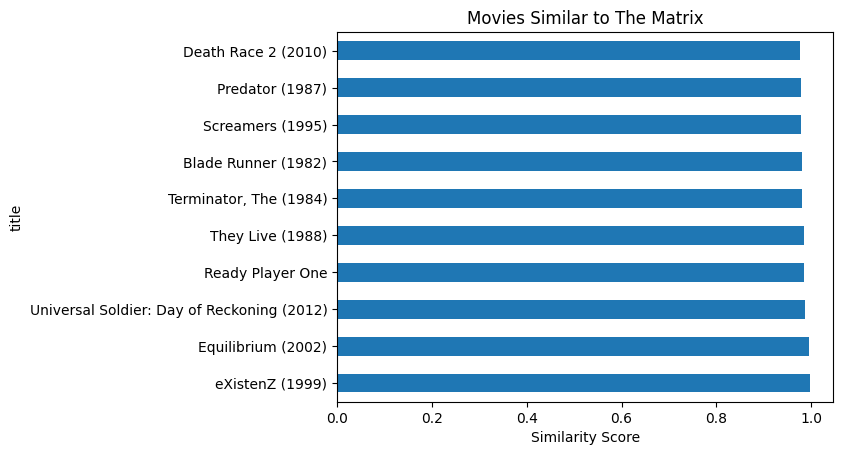

In [78]:
similar = get_similar_movies("Matrix, The (1999)")

similar.plot(kind="barh")
plt.title("Movies Similar to The Matrix")
plt.xlabel("Similarity Score")
plt.show()

In [79]:
get_similar_movies("Inception (2010)")

title
Watchmen (2009)                                          0.954955
Super 8 (2011)                                           0.900071
Fast Five (Fast and the Furious 5, The) (2011)           0.843594
V for Vendetta (2006)                                    0.838451
Iron Man 3 (2013)                                        0.837038
Transformers (2007)                                      0.834977
Riddick (2013)                                           0.834627
RoboCop (2014)                                           0.834318
I Am Number Four (2011)                                  0.832231
Fast & Furious 6 (Fast and the Furious 6, The) (2013)    0.825152
Name: Inception (2010), dtype: float64

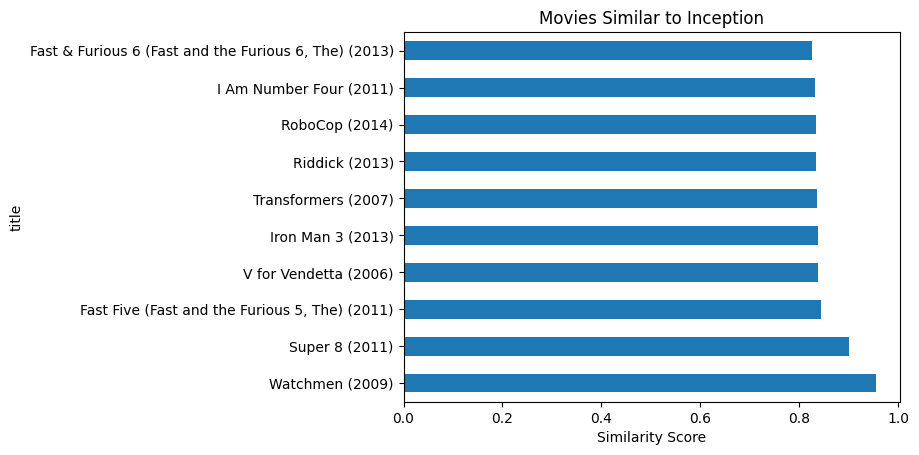

In [81]:
similar = get_similar_movies("Inception (2010)")

similar.plot(kind="barh")
plt.title("Movies Similar to Inception")
plt.xlabel("Similarity Score")
plt.show()

In [80]:
get_similar_movies("Interstellar (2014)")

title
Cloud Atlas (2012)                              0.972049
Edge of Tomorrow (2014)                         0.957377
Contagion (2011)                                0.957179
Gravity (2013)                                  0.955577
Transcendence (2014)                            0.947160
The Amazing Spider-Man 2 (2014)                 0.941333
Elysium (2013)                                  0.926582
Men in Black III (M.III.B.) (M.I.B.³) (2012)    0.925232
Real Steel (2011)                               0.921807
Day the Earth Stood Still, The (2008)           0.918096
Name: Interstellar (2014), dtype: float64

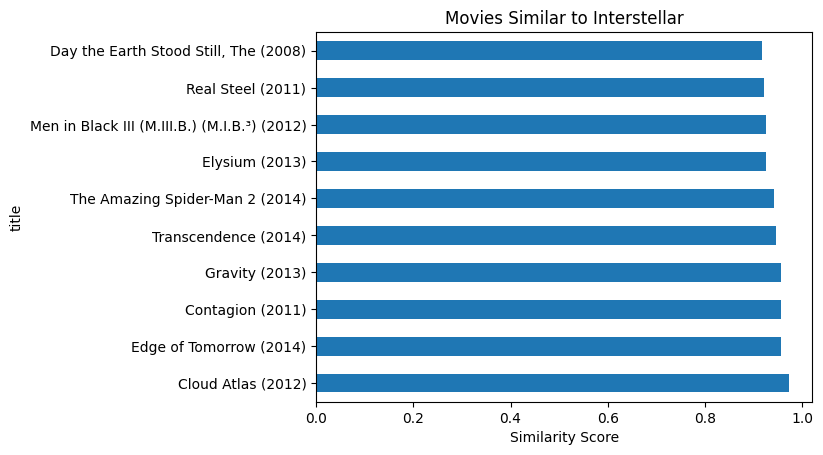

In [82]:
similar = get_similar_movies("Interstellar (2014)")

similar.plot(kind="barh")
plt.title("Movies Similar to Interstellar")
plt.xlabel("Similarity Score")
plt.show()

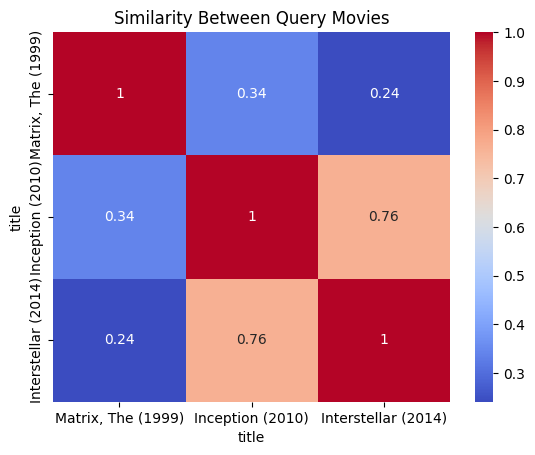

In [83]:
query_movies = [
    "Matrix, The (1999)",
    "Inception (2010)",
    "Interstellar (2014)"
]

heatmap_data = similarity_df.loc[query_movies, query_movies]

sns.heatmap(heatmap_data, annot=True, cmap="coolwarm")
plt.title("Similarity Between Query Movies")
plt.show()